# Práctica 2: Estadística descriptiva

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

pd.set_option("display.max_columns", 40)

PATH_INPUT = "../data/processed/spotify_cleaned.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUMERIC_COLS = [
    "streams", "weeks_on_chart", "rank", "peak_rank",
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration",
]

## Carga de datos

In [2]:
df = pd.read_csv(PATH_INPUT)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas.")
df.head()

Dimensiones: 66174 filas x 36 columnas.


,unnamed_0,uri,rank,artist_names,artists_num,artist_individual,artist_id,artist_genre,artist_img,collab,track_name,release_date,album_num_tracks,album_cover,source,peak_rank,previous_rank,weeks_on_chart,streams,week,danceability,energy,key,mode,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,country,region,language,pivot
0,29477,spotify:track:4ZtFanR9U6ndgddUvNcjcG,1,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,good 4 u,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,1,1,3,3612666,03-06-2021,0.563,0.664,9,1,-5.044,0.1540,0.335,0.000000,0.0849,0.6880,166.928,178147,Australia,Oceania,English,0
1,29478,spotify:track:6HU7h9RYOaPRFeh0R3UeAr,3,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,deja vu,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,2,2,9,1666474,03-06-2021,0.442,0.612,2,1,-7.222,0.1120,0.584,0.000006,0.3700,0.1780,180.917,215507,Australia,Oceania,English,0
2,29479,spotify:track:5CZ40GBx1sQ9agT82CLQCT,4,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,traitor,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,4,6,2,1433290,03-06-2021,0.380,0.339,3,1,-7.885,0.0338,0.691,0.000000,0.1200,0.0849,100.607,229227,Australia,Oceania,English,0
3,29480,spotify:track:5wANPM4fQCJwkGd4rN57mH,6,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,drivers license,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,1,5,21,1266266,03-06-2021,0.561,0.431,10,1,-8.810,0.0578,0.768,0.000014,0.1060,0.1370,143.875,242013,Australia,Oceania,English,0
4,29481,spotify:track:5JCoSi02qi3jJeHdZXMmR8,7,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,favorite crime,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,7,15,2,1184068,03-06-2021,0.369,0.272,9,1,-10.497,0.0364,0.866,0.000000,0.1470,0.2180,172.929,152667,Australia,Oceania,English,0


## Estadística descriptiva (funciones de agregación)

Se calculan, sobre las variables numéricas relevantes (streams, features de audio, duración, rank, semanas en el chart): **mínimo, máximo, conteo, sumatoria, media, varianza, desviación estándar, asimetría (skewness) y curtosis (kurtosis)**.

In [3]:
num = df[NUMERIC_COLS]

resumen = num.agg(["min", "max", "count", "sum", "mean", "var", "std", "skew", "kurt"]).T
resumen = resumen.rename(columns={
    "min": "mínimo", "max": "máximo", "count": "conteo", "sum": "sumatoria",
    "mean": "media", "var": "varianza", "std": "desv_estándar",
    "skew": "asimetría", "kurt": "curtosis",
}).round(3)

resumen.to_csv(os.path.join(OUTPUT_DIR, "resumen_estadistico.csv"))
resumen

,mínimo,máximo,conteo,sumatoria,media,varianza,desv_estándar,asimetría,curtosis
streams,36891.000,3972048.000,66174.0,1.919193e+10,290022.191,6.922641e+10,263109.128,3.115,17.663
weeks_on_chart,1.000,290.000,66174.0,2.710535e+06,40.961,2.440622e+03,49.403,1.941,3.792
rank,1.000,200.000,66174.0,6.475097e+06,97.850,3.365588e+03,58.014,0.050,-1.207
peak_rank,1.000,200.000,66174.0,2.583178e+06,39.036,2.062720e+03,45.417,1.373,1.067
danceability,0.156,0.980,66174.0,4.448849e+04,0.672,2.000000e-02,0.142,-0.503,-0.150
energy,0.022,0.989,66174.0,4.292884e+04,0.649,2.800000e-02,0.168,-0.458,-0.238
loudness,-31.160,-1.148,66174.0,-4.214087e+05,-6.368,5.074000e+00,2.252,-1.202,3.598
speechiness,0.023,0.723,66174.0,7.043037e+03,0.106,1.000000e-02,0.101,1.738,2.689
acousticness,0.000,0.994,66174.0,1.463703e+04,0.221,6.000000e-02,0.246,1.280,0.718
instrumentalness,0.000,0.948,66174.0,5.578530e+02,0.008,4.000000e-03,0.061,10.257,117.325


In [4]:
print("Moda de las variables numéricas:")
num.mode().iloc[0]

Moda de las variables numéricas:


streams             237752.0000
weeks_on_chart           1.0000
rank                    12.0000
peak_rank                1.0000
danceability             0.8240
energy                   0.8250
loudness                -3.4240
speechiness              0.1260
acousticness             0.0076
instrumentalness         0.0000
liveness                 0.1110
valence                  0.4640
tempo                  122.9800
duration            169153.0000
Name: 0, dtype: float64

In [5]:
print("Moda de variables categóricas (país, género, artista):")
for col in ["country", "artist_genre", "artist_individual"]:
    print(f"  {col}: {df[col].mode().iloc[0]}")

Moda de variables categóricas (país, género, artista):
  country: Canada
  artist_genre: pop
  artist_individual: The Weeknd


### Resúmen 

De acuerdo a los resultados que obtuvimos de las funciones de agregación podemos observar que:

- `streams` y `weeks_on_chart` Presentan una asimetría positiva fuerte (3.11 y 1.94) y alta curtosis (17.66 y 3.79). Esto sugiere que la mayoría de tracks en el dataset tienen reproducciones modestas (~290K) y duran pocas semanas en listas (moda de 1 semana en `weeks_on_chart`), mientras que una cantidad muy reducida de tracks estira la cola derecha hasta casi 4 millones de streams.

- `peak_rank` Presenta asimetría positiva (1.37) con moda en 1.0. Esto quiere decir que muchos temas logran alcanzar el top o puestos altos en su pico, pero la media general ronda el puesto 39.

- `rank` Presenta una distribución prácticamente uniforme o simétrica (asimetría 0.05, curtosis -1.20) a lo largo del top 200, con una media de ~98 y una desviación estándar amplia de 58.

- `instrumentalness` Es un caso de asimetría extrema de 10.25 y curtosis de 117.32 con media de apenas 0.008 y moda en 0. Esto significa que prácticamente el 100% de las canciones tienen letra, los tracks o canciones puramente instrumentales son anomalías estadísticas.

- `danceability` y `energy` Presentan un leve sesgo negativo (-0.50 y -0.45) con medias altas (~0.67 y ~0.65) y modas sobre 0.82. Esto quiere decir que hay mas canciones rítmicas, y energéticas que tranquilas y menos energéticas.

- `loudness` Presenta una asimetría negativa fuerte (-1.20) con media de -6.37 dB y moda en -3.42 dB. Esto indica que la gran mayoría de canciones tiene volúmenes altos y comprimidos.

- `tempo` y `valence` Son las variables de audio más equilibradas y simétricas (asimetría de 0.40 y -0.07). El tempo promedio es de 120.89 BPM, el cúal es el estándar de música pop/dance comercial y el ánimo (`valence`) parece equilibrado en casi todas las canciones media de 0.52 y moda de 0.46.

- `duration` Es la duración promedio, la media es de ~204 segundos (~3.4 minutos) con una moda de ~169 segundos (~2.8 minutos) y asimetría positiva (1.58), reflejando una tendencia hacia canciones cada vez más cortas.

Finalmente vemos que las listas estan dominadas por Canadá, el género pop y el artista The Weeknd.

## Identificación de entidades y relaciones

El dataset es una tabla plana desnormalizada, cada fila mezcla información de una canción, uno de sus artistas, su país/región/idioma y una entrada semanal del chart. A partir de las dependencias funcionales observadas en los datos (una canción con 2 artistas aparece duplicada una fila por artista, con streams/rank/week/country repetidos; un país determina siempre la misma región e idioma) se identifican 5 entidades:

| Entidad | PK | Atributos |
|---|---|---|
| **ARTISTA** | `artist_id` | artist_individual, artist_genre, artist_img |
| **CANCION** | `uri` | track_name, release_date, album_num_tracks, duration, danceability, energy, key, mode, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo |
| **PAIS** | `country` | region, language |
| **CANCION_ARTISTA** *(tabla puente M:N)* | `(uri, artist_id)` | - |
| **ENTRADA_CHART** *(tabla de hechos)* | `(uri, country, week)` | rank, peak_rank, previous_rank, weeks_on_chart, streams, source, pivot |

**Relaciones:**
- `ARTISTA (1) --- (N) CANCION_ARTISTA (N) --- (1) CANCION` → relación **M:N** Artista-Canción (colaboraciones)
- `CANCION (1) --- (N) ENTRADA_CHART` → una canción tiene muchas entradas de chart (una por semana/país)
- `PAIS (1) --- (N) ENTRADA_CHART` → un país tiene muchas entradas de chart

**Evidencia basada en los datos:** Por ejemplo, la canción "Kiss Me More" (Doja Cat, SZA) aparece 2 veces para la misma semana/país, una fila por artista, con el mismo streams/rank lo cual indica una relación M:N aplanada en una sola tabla.

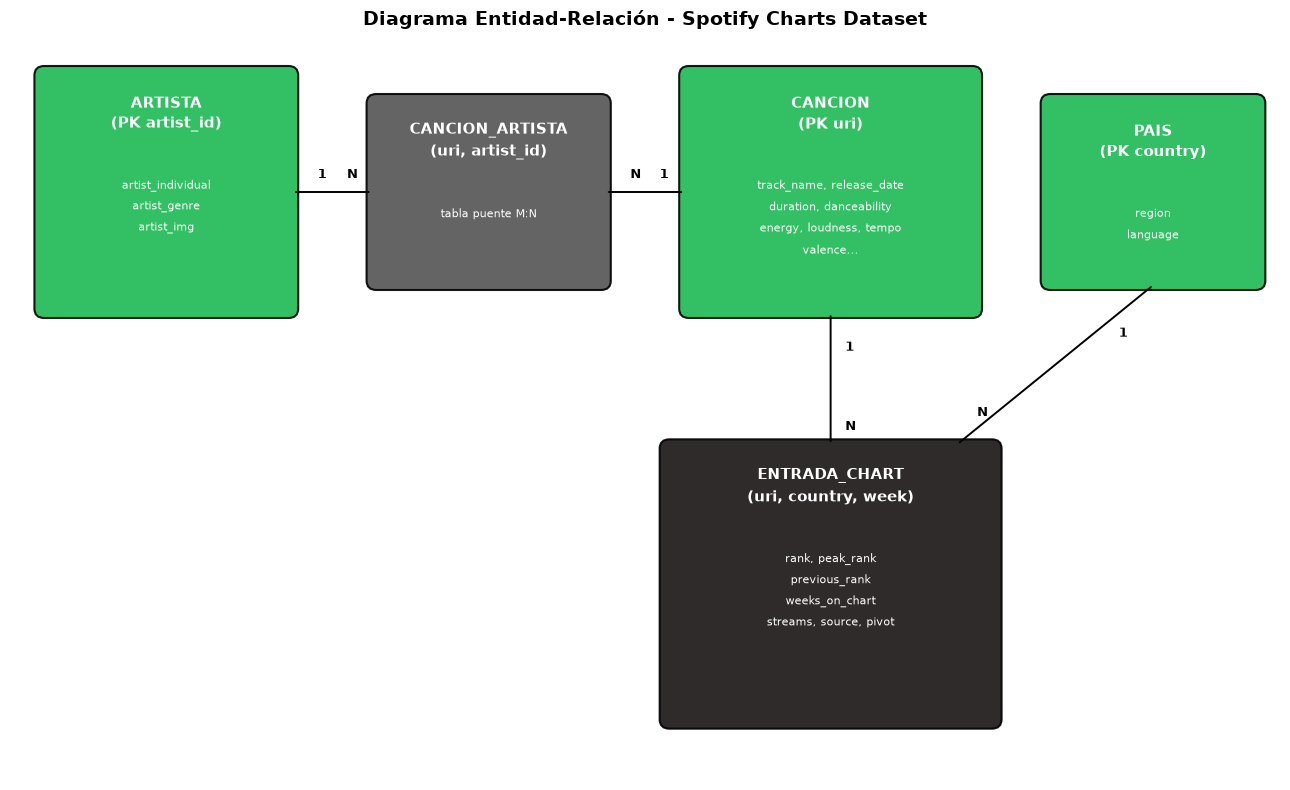

In [6]:
def dibujar_diagrama_er():
    fig, ax = plt.subplots(figsize=(13, 8))
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 8)
    ax.axis("off")

    def caja(x, y, w, h, titulo, attrs, color="#1DB954"):
        box = mpatches.FancyBboxPatch(
            (x, y), w, h, boxstyle="round,pad=0.05,rounding_size=0.1",
            linewidth=1.5, edgecolor="black", facecolor=color, alpha=0.9
        )
        ax.add_patch(box)
        n_title_lines = titulo.count("\n") + 1
        title_y = y + h - 0.22
        ax.text(x + w / 2, title_y, titulo, ha="center", va="top",
                 fontsize=10.5, fontweight="bold", color="white", linespacing=1.5)
        attrs_y = title_y - n_title_lines * 0.36 - 0.18
        ax.text(x + w / 2, attrs_y, attrs, ha="center", va="top",
                 fontsize=8, color="white", linespacing=1.9)
        return (x, y, w, h)

    artista = caja(0.3, 5.0, 2.6, 2.6, "ARTISTA\n(PK artist_id)",
                    "artist_individual\nartist_genre\nartist_img", "#1DB954")
    puente = caja(3.7, 5.3, 2.4, 2.0, "CANCION_ARTISTA\n(uri, artist_id)",
                   "tabla puente M:N", "#535353")
    cancion = caja(6.9, 5.0, 3.0, 2.6, "CANCION\n(PK uri)",
                    "track_name, release_date\nduration, danceability\nenergy, loudness, tempo\nvalence...", "#1DB954")
    pais = caja(10.6, 5.3, 2.2, 2.0, "PAIS\n(PK country)",
                 "region\nlanguage", "#1DB954")
    entrada = caja(6.7, 0.6, 3.4, 3.0, "ENTRADA_CHART\n(uri, country, week)",
                    "rank, peak_rank\nprevious_rank\nweeks_on_chart\nstreams, source, pivot", "#191414")

    def flecha(p1, p2):
        ax.annotate("", xy=p2, xytext=p1,
                     arrowprops=dict(arrowstyle="-", lw=1.4, color="black"))

    flecha((2.9, 6.3), (3.7, 6.3))
    flecha((6.1, 6.3), (6.9, 6.3))
    flecha((8.4, 5.0), (8.4, 3.6))
    flecha((11.7, 5.3), (9.7, 3.6))

    ax.text(3.15, 6.45, "1", fontsize=9, fontweight="bold")
    ax.text(3.45, 6.45, "N", fontsize=9, fontweight="bold")
    ax.text(6.35, 6.45, "N", fontsize=9, fontweight="bold")
    ax.text(6.65, 6.45, "1", fontsize=9, fontweight="bold")
    ax.text(8.55, 4.6, "1", fontsize=9, fontweight="bold")
    ax.text(8.55, 3.75, "N", fontsize=9, fontweight="bold")
    ax.text(11.35, 4.75, "1", fontsize=9, fontweight="bold")
    ax.text(9.9, 3.9, "N", fontsize=9, fontweight="bold")

    ax.set_title("Diagrama Entidad-Relación - Spotify Charts Dataset",
                  fontsize=14, fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "diagrama_er.png"), dpi=150)
    plt.show()

dibujar_diagrama_er()

## Álgebra relacional

Operaciones de álgebra relacional aplicadas sobre el dataset usando pandas.

### Transposición

In [7]:
audio_cols = ["danceability", "energy", "valence", "tempo"]
df[audio_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
danceability,66174.0,0.672,0.142,0.156,0.579,0.686,0.780,0.980
energy,66174.0,0.649,0.168,0.022,0.530,0.669,0.782,0.989
valence,66174.0,0.524,0.230,0.032,0.354,0.514,0.716,0.978
tempo,66174.0,120.891,27.306,40.319,99.983,121.932,140.002,208.918


### Selección: Canciones de Canadá con streams > 1,000,000

In [8]:
seleccion = df[(df["country"] == "Canada") & (df["streams"] > 1_000_000)]
print(f"{len(seleccion)} filas seleccionadas de {len(df)}")
seleccion.head()

789 filas seleccionadas de 66174


,unnamed_0,uri,rank,artist_names,artists_num,artist_individual,artist_id,artist_genre,artist_img,collab,track_name,release_date,album_num_tracks,album_cover,source,peak_rank,previous_rank,weeks_on_chart,streams,week,danceability,energy,key,mode,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration,country,region,language,pivot
21747,186962,spotify:track:4ZtFanR9U6ndgddUvNcjcG,2,Olivia Rodrigo,1,Olivia Rodrigo,spotify:artist:1McMsnEElThX1knmY4oliG,pop,https://i.scdn.co/image/ab6761610000e5ebee954a...,0,good 4 u,21-05-2021,11,https://i.scdn.co/image/ab67616d0000b273a91c10...,Olivia Rodrigo PS,1,1,9,1732495,15-07-2021,0.563,0.664,9,1,-5.044,0.1540,0.3350,0.000000,0.0849,0.688,166.928,178147,Canada,North America,English,0
21748,186963,spotify:track:6PQ88X9TkUIAUIZJHW2upE,3,Ed Sheeran,1,Ed Sheeran,spotify:artist:6eUKZXaKkcviH0Ku9w2n3V,pop,https://i.scdn.co/image/ab6761610000e5eb12a2ef...,0,Bad Habits,25-06-2021,1,https://i.scdn.co/image/ab67616d0000b2734e03a2...,Atlantic Records UK,2,2,3,1557969,15-07-2021,0.808,0.897,11,0,-3.712,0.0348,0.0469,0.000031,0.3640,0.591,126.026,231041,Canada,North America,English,0
21749,186964,spotify:track:40uMIn2zJLAQhNXghRjBed,4,Post Malone,1,Post Malone,spotify:artist:246dkjvS1zLTtiykXe5h60,dfw rap,https://i.scdn.co/image/ab6761610000e5ebb894ef...,0,Motley Crew,09-07-2021,1,https://i.scdn.co/image/ab67616d0000b2733520e9...,Republic Records,4,-1,1,1426111,15-07-2021,0.797,0.631,3,0,-3.818,0.0786,0.0904,0.000004,0.0998,0.288,129.915,184213,Canada,North America,English,0
21750,186965,spotify:track:3Wrjm47oTz2sjIgck11l5e,5,Måneskin,1,Måneskin,spotify:artist:0lAWpj5szCSwM4rUMHYmrr,indie rock italiano,https://i.scdn.co/image/ab6761610000e5ebbbeb46...,0,Beggin',08-12-2017,7,https://i.scdn.co/image/ab67616d0000b273fa0ab3...,RCA Records Label,3,3,4,1365828,15-07-2021,0.714,0.800,11,0,-4.808,0.0504,0.1270,0.000000,0.3590,0.589,134.002,211560,Canada,North America,English,0
21751,186966,spotify:track:67BtfxlNbhBmCDR2L2l8qd,8,Lil Nas X,1,Lil Nas X,spotify:artist:7jVv8c5Fj3E9VhNjxT4snq,pop,https://i.scdn.co/image/ab6761610000e5ebab6bd6...,0,MONTERO (Call Me By Your Name),31-03-2021,3,https://i.scdn.co/image/ab67616d0000b273664034...,Columbia,1,5,16,1077506,15-07-2021,0.610,0.508,8,0,-6.682,0.1520,0.2970,0.000000,0.3840,0.758,178.818,137876,Canada,North America,English,0


Como podemos observar obtuvimos 789 filas de 66174, lo que indica que hay 789 canciones de Canadá con mas de 1M de streams

### Proyección: Columnas `track_name`, `artist_individual`, `streams`

Aplicamos proyección a la selección anterior

In [9]:
proyeccion = seleccion[["track_name", "artist_individual", "streams"]].drop_duplicates()
proyeccion.head(10)

,track_name,artist_individual,streams
21747,good 4 u,Olivia Rodrigo,1732495
21748,Bad Habits,Ed Sheeran,1557969
21749,Motley Crew,Post Malone,1426111
21750,Beggin',Måneskin,1365828
21751,MONTERO (Call Me By Your Name),Lil Nas X,1077506
21867,good 4 u,Olivia Rodrigo,2038609
21868,Bad Habits,Ed Sheeran,1532393
21869,MONTERO (Call Me By Your Name),Lil Nas X,1247128
21870,Beggin',Måneskin,1067778
21988,Bad Habits,Ed Sheeran,1596469


### Unión: top-10 canciones de Australia UNIDO con top-10 de Irlanda (por streams)

In [10]:
top_aus = df[df["country"] == "Australia"].nlargest(10, "streams")[["track_name", "country", "streams"]]
top_irl = df[df["country"] == "Ireland"].nlargest(10, "streams")[["track_name", "country", "streams"]]
union = pd.concat([top_aus, top_irl], ignore_index=True).drop_duplicates()
print(f"{len(top_aus)} + {len(top_irl)} filas -> unión de {len(union)} filas")
union

10 + 10 filas -> unión de 18 filas


,track_name,country,streams
0,good 4 u,Australia,3972048
1,good 4 u,Australia,3612666
2,First Class,Australia,3439731
3,good 4 u,Australia,3027435
4,STAY (with Justin Bieber),Australia,2876358
6,STAY (with Justin Bieber),Australia,2867230
8,Easy On Me,Australia,2848027
9,STAY (with Justin Bieber),Australia,2834547
10,Easy On Me,Ireland,1387829
11,good 4 u,Ireland,1209884


### Join: Normalización en las 5 entidades y reconstrucción

Se descompone la tabla plana en las entidades identificadas anteriormente, y luego se reconstruye con `merge` para comprobar que el álgebra relacional (proyección + join) recupera la información original.

In [11]:
artistas = df[["artist_id", "artist_individual", "artist_genre"]].drop_duplicates("artist_id")
canciones = df[["uri", "track_name", "release_date", "duration",
                 "danceability", "energy", "tempo"]].drop_duplicates("uri")
paises = df[["country", "region", "language"]].drop_duplicates("country")
cancion_artista = df[["uri", "artist_id"]].drop_duplicates()
entradas = df[["uri", "country", "week", "rank", "streams"]].drop_duplicates()

print(f"ARTISTA: {len(artistas)} filas | CANCION: {len(canciones)} filas | PAIS: {len(paises)} filas")
print(f"CANCION_ARTISTA: {len(cancion_artista)} filas | ENTRADA_CHART: {len(entradas)} filas")

ARTISTA: 1108 filas | CANCION: 2445 filas | PAIS: 3 filas
CANCION_ARTISTA: 3602 filas | ENTRADA_CHART: 45600 filas


In [12]:
reconstruida = (
    entradas
    .merge(canciones, on="uri", how="left")
    .merge(paises, on="country", how="left")
    .merge(cancion_artista, on="uri", how="left")
    .merge(artistas, on="artist_id", how="left")
)
print(f"Reconstrucción vía joins: {len(reconstruida)} filas (original desnormalizado: {len(df)} filas)")
reconstruida.head()

Reconstrucción vía joins: 66174 filas (original desnormalizado: 66174 filas)


,uri,country,week,rank,streams,track_name,release_date,duration,danceability,energy,tempo,region,language,artist_id,artist_individual,artist_genre
0,spotify:track:4ZtFanR9U6ndgddUvNcjcG,Australia,03-06-2021,1,3612666,good 4 u,21-05-2021,178147,0.563,0.664,166.928,Oceania,English,spotify:artist:1McMsnEElThX1knmY4oliG,Olivia Rodrigo,pop
1,spotify:track:6HU7h9RYOaPRFeh0R3UeAr,Australia,03-06-2021,3,1666474,deja vu,21-05-2021,215507,0.442,0.612,180.917,Oceania,English,spotify:artist:1McMsnEElThX1knmY4oliG,Olivia Rodrigo,pop
2,spotify:track:5CZ40GBx1sQ9agT82CLQCT,Australia,03-06-2021,4,1433290,traitor,21-05-2021,229227,0.380,0.339,100.607,Oceania,English,spotify:artist:1McMsnEElThX1knmY4oliG,Olivia Rodrigo,pop
3,spotify:track:5wANPM4fQCJwkGd4rN57mH,Australia,03-06-2021,6,1266266,drivers license,21-05-2021,242013,0.561,0.431,143.875,Oceania,English,spotify:artist:1McMsnEElThX1knmY4oliG,Olivia Rodrigo,pop
4,spotify:track:5JCoSi02qi3jJeHdZXMmR8,Australia,03-06-2021,7,1184068,favorite crime,21-05-2021,152667,0.369,0.272,172.929,Oceania,English,spotify:artist:1McMsnEElThX1knmY4oliG,Olivia Rodrigo,pop


### Agrupación: Streams promedio por país

In [13]:
df.groupby("country")["streams"].mean().round(0)

country
Australia    394438.0
Canada       385228.0
Ireland       83878.0
Name: streams, dtype: float64

## Métricas de datos agrupados

### Streams totales y promedio por país

In [14]:
por_pais = df.groupby("country")["streams"].agg(["sum", "mean", "count"]).round(0)
por_pais

,sum,mean,count
country,,,
Australia,8577834547,394438.0,21747
Canada,8804769791,385228.0,22856
Ireland,1809324137,83878.0,21571


### Promedio de features de audio por género (top 8 géneros más frecuentes)

**Nota:** en el dataset original, aparece el valor `"0"` en `artist_genre` el cual no es un género real pero en el dataset el `0` es un placeholder que usa la fuente de datos para artistas sin género catalogado en Spotify (puede ser porque el artista no ha sido catalogado bajo un genero por ser nuevo, con pocos streams o porque su contenido aun no ha sido revisado). Se excluye aquí para poder comparar solo géneros catalogados en el dataset.

In [15]:
top_generos = df.loc[df["artist_genre"] != "0", "artist_genre"].value_counts().head(8).index
por_genero = (
    df[df["artist_genre"].isin(top_generos)]
    .groupby("artist_genre")[["danceability", "energy", "valence", "tempo"]]
    .mean()
    .round(3)
    .loc[top_generos]
)
por_genero

,danceability,energy,valence,tempo
artist_genre,,,,
pop,0.627,0.612,0.476,121.575
dance pop,0.705,0.700,0.577,117.696
rap,0.744,0.641,0.479,121.494
uk pop,0.643,0.630,0.528,112.852
hip hop,0.752,0.643,0.459,123.001
chicago rap,0.709,0.617,0.411,117.087
canadian pop,0.654,0.638,0.458,123.417
pop rap,0.718,0.733,0.629,115.037


### Top 10 artistas por streams totales (canciones únicas)

In [16]:
top_artistas = (
    df.drop_duplicates(["uri", "country", "week", "artist_id"])
    .groupby("artist_individual")["streams"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_artistas

artist_individual
Olivia Rodrigo    522086632
Justin Bieber     520307923
Drake             449011004
Doja Cat          434304074
The Weeknd        427441918
Ed Sheeran        407251206
Dua Lipa          341750046
The Kid LAROI     327796866
Lil Nas X         309151649
Harry Styles      279256684
Name: streams, dtype: int64

### Semanas promedio en el chart (weeks_on_chart) por país

In [17]:
df.groupby("country")["weeks_on_chart"].mean().round(1)

country
Australia    50.3
Canada       33.9
Ireland      39.1
Name: weeks_on_chart, dtype: float64

### Gráficas de métricas agrupadas

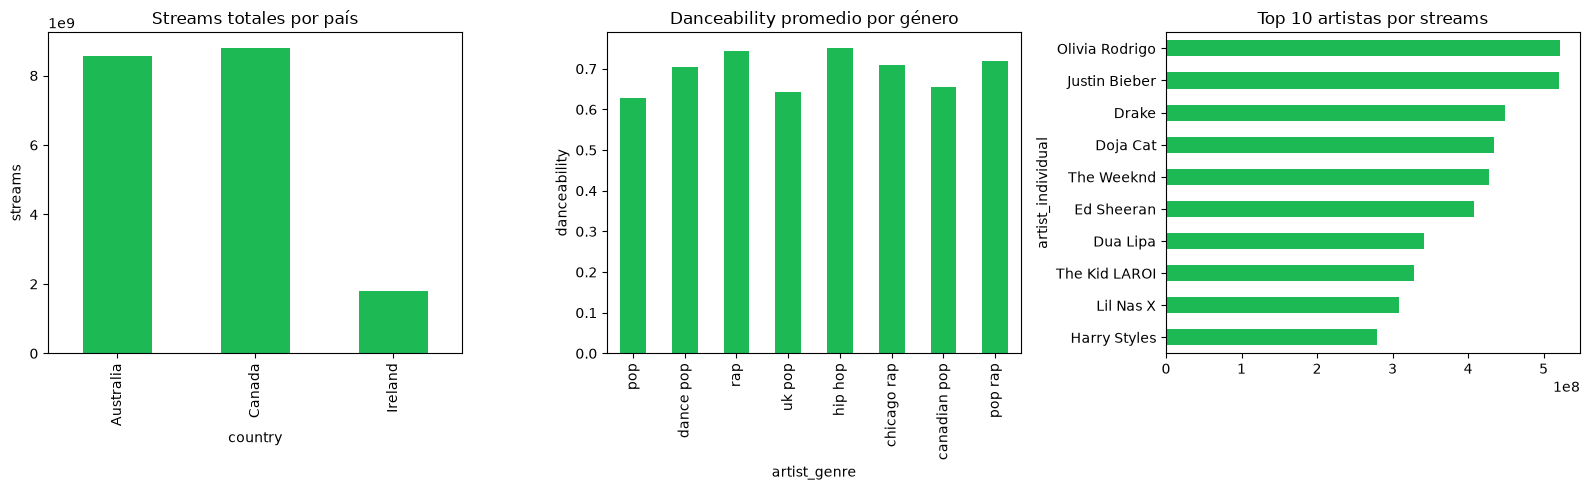

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

por_pais["sum"].plot(kind="bar", ax=axes[0], color="#1DB954")
axes[0].set_title("Streams totales por país")
axes[0].set_ylabel("streams")

por_genero["danceability"].plot(kind="bar", ax=axes[1], color="#1DB954")
axes[1].set_title("Danceability promedio por género")
axes[1].set_ylabel("danceability")

top_artistas.plot(kind="barh", ax=axes[2], color="#1DB954")
axes[2].set_title("Top 10 artistas por streams")
axes[2].invert_yaxis()

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "metricas_agrupadas.png"), dpi=150)
plt.show()

## Relaciones entre variables numéricas (matriz de correlación)

Esto nos sirve para visualizar como se relacionan o que tanto se relaciona una variable con otra. En este caso usaremos variables numericas y generaremos la matriz de correlación.

In [19]:
corr_cols = ["streams", "danceability", "energy", "loudness", "valence", "tempo", "weeks_on_chart"]
corr = df[corr_cols].corr().round(2)
corr

,streams,danceability,energy,loudness,valence,tempo,weeks_on_chart
streams,1.00,0.06,-0.03,-0.01,0.03,0.05,-0.17
danceability,0.06,1.00,0.13,0.17,0.38,-0.13,-0.13
energy,-0.03,0.13,1.00,0.67,0.41,0.12,-0.05
loudness,-0.01,0.17,0.67,1.00,0.27,-0.02,0.02
valence,0.03,0.38,0.41,0.27,1.00,0.03,0.01
tempo,0.05,-0.13,0.12,-0.02,0.03,1.00,-0.06
weeks_on_chart,-0.17,-0.13,-0.05,0.02,0.01,-0.06,1.00


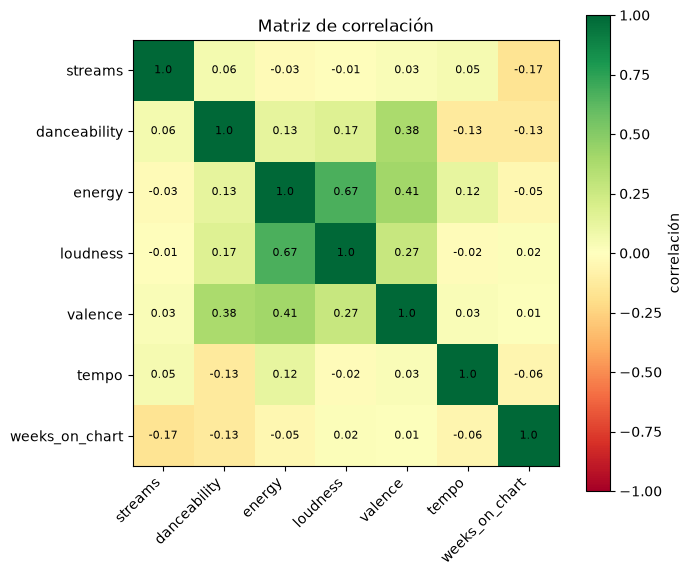

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="correlación")
ax.set_title("Matriz de correlación")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "matriz_correlacion.png"), dpi=150)
plt.show()